In [2]:
import keras
from keras import layers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from metrics_tracking import F1Score, plot_metrics

In [3]:
OTIDS_file_colab = "OTIDS_clean_data.npz"
OTIDS_file_local = "Preprocessed_Data/OTIDS_clean_data.npz"
data = np.load(OTIDS_file_local)
# Access arrays by the names you used when saving
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
y_train = y_train.astype("int32").ravel()
y_test  = y_test.astype("int32").ravel()

In [22]:
def create_model_otids():
    inp = keras.Input(shape=(600, 11))
    x = layers.Conv1D(64, 12, activation='relu')(inp)
    x_max = layers.GlobalMaxPooling1D()(x)
    x_avg = layers.GlobalAveragePooling1D()(x)
    x = layers.Concatenate()([x_max, x_avg])
    x = layers.Dense(16, activation='relu')(x)   # optional small dense
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    return model
#1d cnn sequential model:
# def create_model_otids(): #this is the same model we'll always use for all.
#     model = keras.Sequential()
#     model.add(layers.Input(shape=(600, 11)))
#     model.add(layers.Conv1D(128, 8, activation='relu'))#64 was pretty decent
#     # # model.add(layers.GlobalMaxPooling1D())
#     # model.add(layers.GlobalAveragePooling1D())
#     x_max = layers.GlobalMaxPooling1D()(x)
#     x_avg = layers.GlobalAveragePooling1D()(x)
#     model.add(layers.Concatenate()([x_max, x_avg]))
#     model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
#     return model
model = create_model_otids()

In [26]:
callbacks = [
    ModelCheckpoint("saved_models/best_model_OTIDS_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-12, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, verbose=1, restore_best_weights=True)
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",   # correct for sigmoid + 0/1 labels
    metrics=[
        keras.metrics.AUC(name="auc"),
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        F1Score(name="f1")
    ]
)
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=60,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
957/957 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9249 - auc: 0.9793 - f1: 0.9270 - loss: 0.1851 - precision: 0.9250 - recall: 0.9289
Epoch 1: val_auc improved from None to 0.87642, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9147 - auc: 0.9749 - f1: 0.9169 - loss: 0.2029 - precision: 0.9170 - recall: 0.9168 - val_accuracy: 0.7922 - val_auc: 0.8764 - val_f1: 0.7869 - val_loss: 0.6126 - val_precision: 0.8365 - val_recall: 0.7427 - learning_rate: 0.0010
Epoch 2/60
956/957 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9274 - auc: 0.9814 - f1: 0.9284 - loss: 0.1767 - precision: 0.9315 - recall: 0.9254
Epoch 2: val_auc did not improve from 0.87642
957/957 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9159 - auc: 0.9753 - f1: 0.9180 - loss: 0.2011 - precision: 0.9188 - recall: 0.9173 - val_accuracy: 0.7798 - val_auc: 0.8756 - val_f1: 0.8011 - val_loss: 0.6218 - val_precision: 0.7510 - val_recall: 0.

In [27]:
testing_acc = model.evaluate(X_test,y_test, verbose=1)
print(f"Test loss: {testing_acc[0]}")
print(f"Test accuracy: {testing_acc[1]}")
print(f"Test AUC: {testing_acc[2]}")
print(f"Test Precision: {testing_acc[3]}")
print(f"Test Recall: {testing_acc[4]}")
print(f"Test F1: {testing_acc[5]}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8006 - auc: 0.8775 - f1: 0.8126 - loss: 0.5865 - precision: 0.7852 - recall: 0.8420
Test loss: 0.5865115523338318
Test accuracy: 0.8775490522384644
Test AUC: 0.8005644679069519
Test Precision: 0.7852262854576111
Test Recall: 0.8420329689979553
Test F1: 0.812637984752655


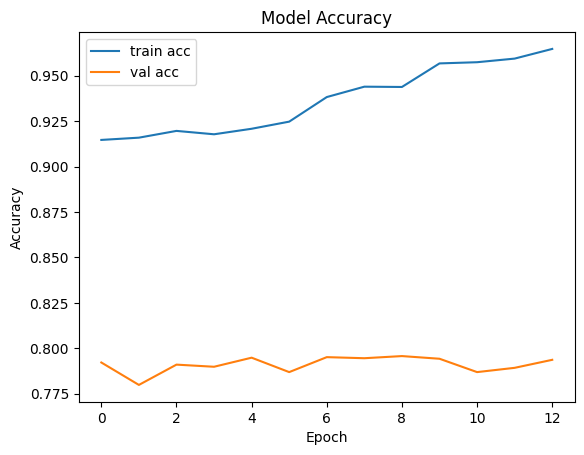

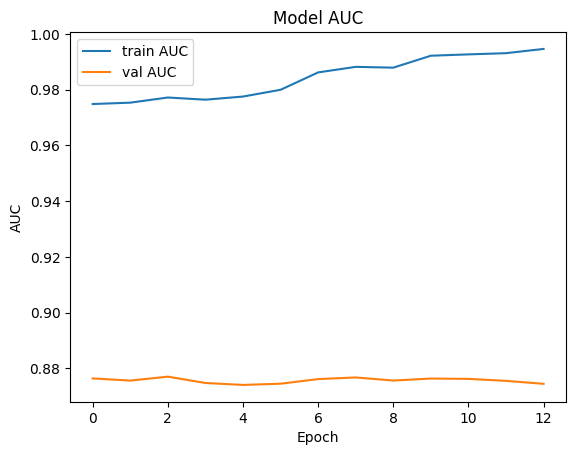

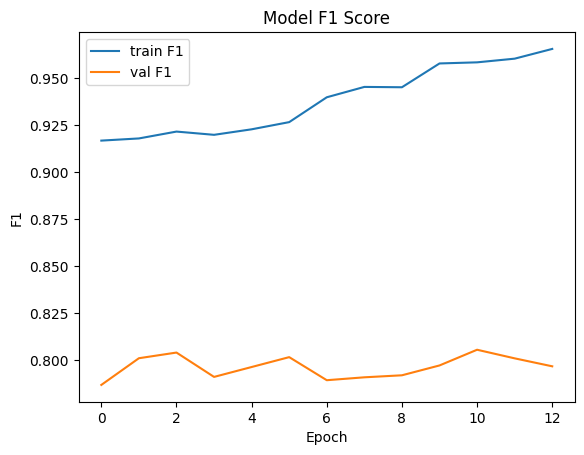

In [28]:
plot_metrics(history)

In [29]:
y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))

# --- Correct ROC-AUC for binary classifier ---
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

     Ambient       0.82      0.76      0.79      4136
      Attack       0.79      0.84      0.81      4368

    accuracy                           0.80      8504
   macro avg       0.80      0.80      0.80      8504
weighted avg       0.80      0.80      0.80      8504

ROC AUC Score: 0.8798


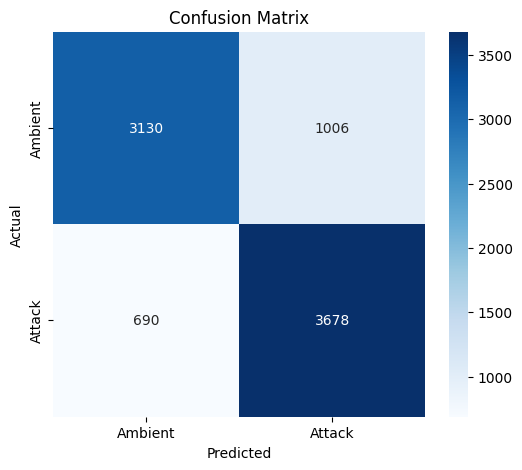

In [30]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Ambient", "Attack"],
    yticklabels=["Ambient", "Attack"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()